# #1. Load Dataset

In [130]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1oBz6GpPe8SNPYHt6qMtv-8yNQUASUJDcFGhsbOPPNZY/export?format=csv"

data = pd.read_csv(url)

print(data.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


# # 2. Data Cleaning

In [131]:
print(data.isnull().sum())
df = data.drop_duplicates()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# # 3.Check data types

In [132]:
data.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [133]:
data[['income','gdpp']]=data[['income','gdpp']].astype(float)

In [134]:
data.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,float64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,float64


# #4.Detect and treat outliers

In [135]:
data['income'].skew()
#If result > +1 → highly right skewed
#If result ≈ 0 → normal
#If result < -1 → left skewed

np.float64(2.231479607767527)

In [136]:
Q1=data['income'].quantile(0.25)
Q3=data['income'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

data['income'] = data['income'].clip(lower, upper)

In [137]:
import numpy as np
data['income'] = np.log1p(data['income'])
#Makes distribution more balanced
#Reduces skewness further

In [138]:
print(data['income'].skew())
#Not highly skewed anymore
#Close to normal distribution
#Outliers impact is already reduced

-0.33635173237529986


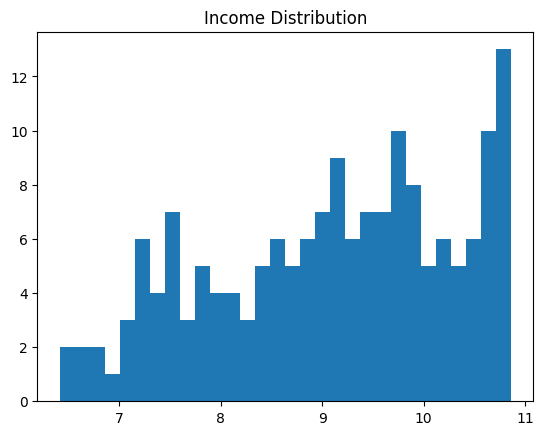

In [139]:
import matplotlib.pyplot as plt

plt.hist(data['income'], bins=30)
plt.title("Income Distribution")
plt.show()

In [140]:
print(data['gdpp'].skew())
print(data['gdpp'].mean())
print(data['gdpp'].median())

2.2180514519497163
12964.155688622754
4660.0


In [141]:
Q1=data['gdpp'].quantile(0.25)
Q3=data['gdpp'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

data['gdpp']=data['gdpp'].clip(lower,upper)

In [142]:
import numpy as np
data['gdpp'] = np.log1p(data['gdpp'])

In [143]:
print(data['gdpp'].skew())

-0.17254945941148797


In [144]:
print(data['child_mort'].skew())
print(data['child_mort'].mean())
print(data['child_mort'].median())


1.4507735387555047
38.27005988023952
19.3


In [145]:
Q1=data['child_mort'].quantile(0.25)
Q3=data['child_mort'].quantile(0.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

data['child_mort']=data['child_mort'].clip(lower,upper)

In [146]:
data['child_mort'] = np.log1p(data['child_mort'])

In [147]:
data['child_mort'].skew()
#Child mortality is highly right skewed due to a few countries with very high mortality rates.
#After capping and log transformation, the distribution becomes approximately symmetric.”

np.float64(0.04431623913033775)

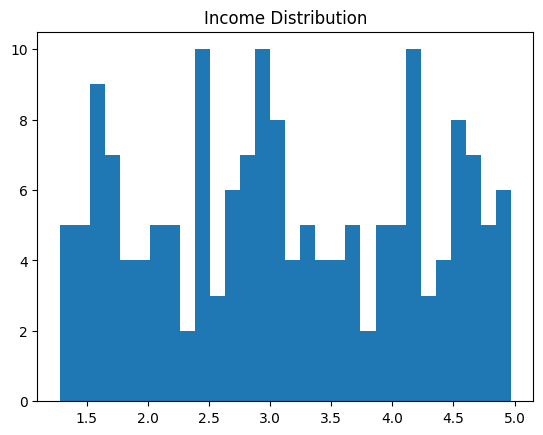

In [148]:
import matplotlib.pyplot as plt

plt.hist(data['child_mort'], bins=30)
plt.title("Income Distribution")
plt.show()

In [149]:
data['inflation'].skew()


np.float64(5.154049359697971)

In [150]:
Q1 = data['inflation'].quantile(0.25)
Q3 = data['inflation'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [151]:
data['inflation'] = data['inflation'].clip(-5, 30)

In [152]:
data['inflation'].skew()

np.float64(1.195050583403216)

In [153]:
import numpy as np

data['inflation'] = np.sign(data['inflation']) * np.log1p(abs(data['inflation']))

In [154]:
data['inflation'].skew()
#After capping and applying a signed log transformation, inflation skewness changed from highly right skewed (~5.15) to left skewed (~-2.25).
# This indicates that extreme values have been controlled, and further transformation is not necessary.”

np.float64(-0.6620467394405519)

# Handle negative or extreme inflation values

In [155]:
df['inflation'].describe()

,inflation
count,167.000000
mean,7.781832
std,10.570704
min,-4.210000
25%,1.810000
50%,5.390000
75%,10.750000
max,104.000000


In [156]:
df['inflation'] = df['inflation'].clip(lower=-10, upper=50)

# Perform consistency checks

In [157]:
numeric_data = data.select_dtypes(include=['number'])
(numeric_data < 0).sum()
#A consistency check was performed to identify negative values in numeric variables using boolean filtering and aggregation

,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,8
life_expec,0
total_fer,0
gdpp,0


In [158]:
data['Development_Index'] = (data['income'] + data['gdpp'] + data['life_expec']) / data['child_mort']

In [159]:
data['Trade_Balance'] = data['exports'] - data['imports']

In [160]:
data['Health_Impact_Ratio'] = data['health'] / data['child_mort']

# #6.Exploratory Data Analysis (Python)

#Univariate Analysis


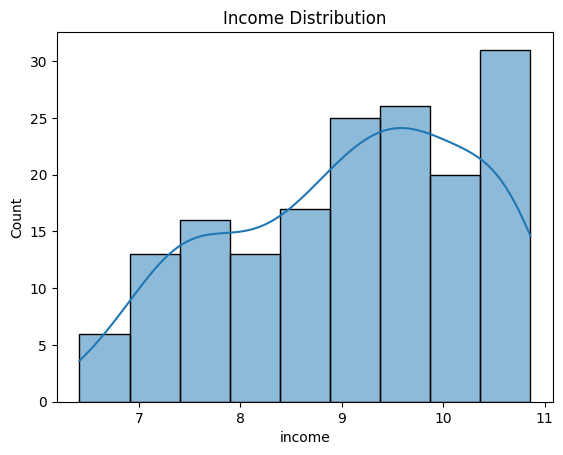

In [161]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data['income'], kde=True)
plt.title("Income Distribution")
plt.show()
#Distribution of income
#Income is positively skewed (right-skewed)
#Majority of countries have low income
#Few countries have extremely high income
#Presence of outliers (rich countries)


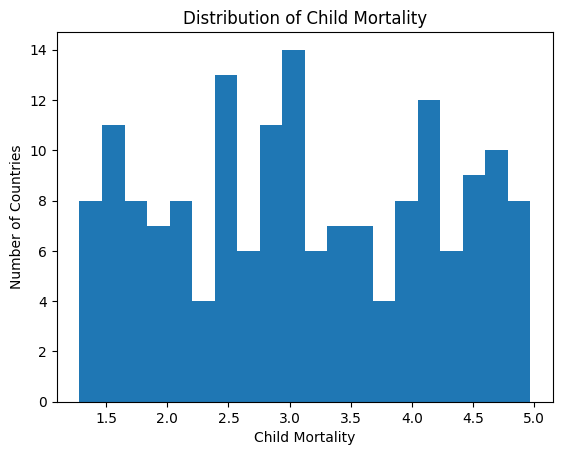

In [162]:
plt.hist(data['child_mort'], bins=20)
plt.xlabel('Child Mortality')
plt.ylabel('Number of Countries')
plt.title('Distribution of Child Mortality')
plt.show()
#The distribution of child mortality is highly right-skewed,
#indicating that most countries have low child mortality rates,
 #while a few countries exhibit extremely high mortality.
 #This highlights significant global disparities in healthcare and living conditions###

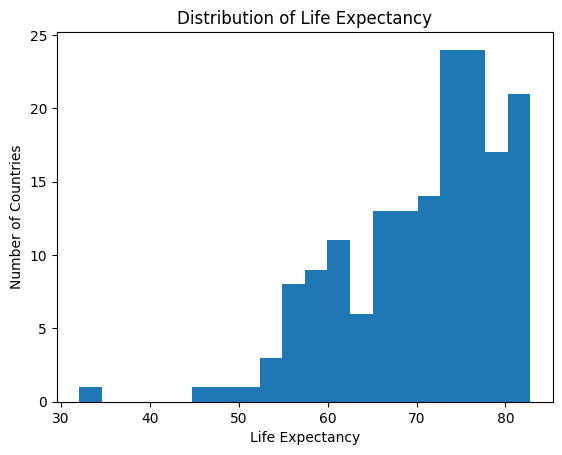

In [163]:
plt.hist(data['life_expec'], bins=20)
plt.xlabel('Life Expectancy')
plt.ylabel('Number of Countries')
plt.title('Distribution of Life Expectancy')
plt.show()
#The distribution of life expectancy is slightly left-skewed,
# with most countries having high life expectancy between 65 and 80 years.
# A few countries show significantly lower values, indicating disparities in healthcare and living conditions across the world.

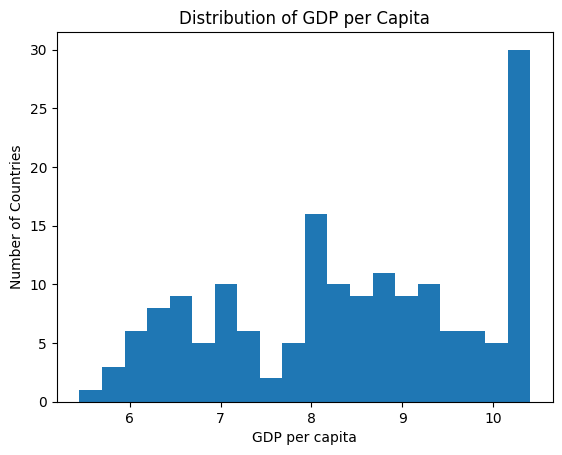

In [164]:
plt.hist(data['gdpp'], bins=20)
plt.xlabel('GDP per capita')
plt.ylabel('Number of Countries')
plt.title('Distribution of GDP per Capita')
plt.show()
#The distribution of GDP per capita is highly right-skewed,
 #with most countries having low to moderate GDP values and a few countries exhibiting extremely high GDP.
 #The wide spread indicates significant economic inequality across countries.

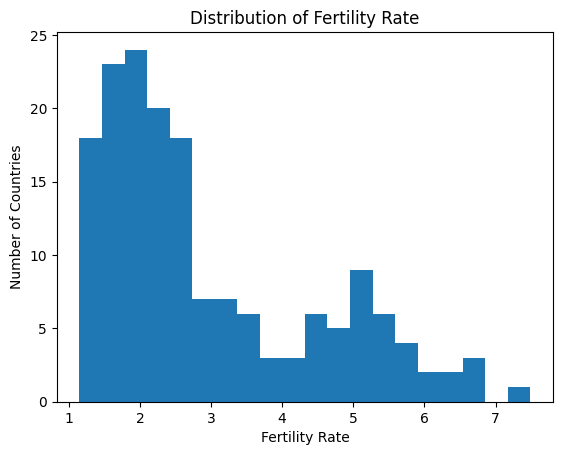

In [165]:
plt.hist(data['total_fer'], bins=20)
plt.xlabel('Fertility Rate')
plt.ylabel('Number of Countries')
plt.title('Distribution of Fertility Rate')
plt.show()
#The distribution of fertility rate is positively skewed, with most countries having low to moderate fertility levels,
#while a few countries exhibit very high fertility rates.
# This reflects significant differences in economic development, healthcare, and population growth patterns across countries.

# Bivariate / Multivariate Analysis


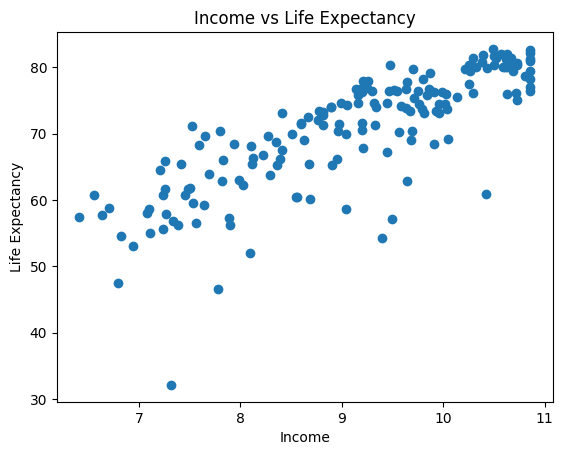

In [166]:
#Income vs Life Expectancy
plt.scatter(data['income'], data['life_expec'])
plt.xlabel('Income')
plt.ylabel('Life Expectancy')
plt.title('Income vs Life Expectancy')
plt.show()
#Positive correlation
#Higher income → Higher life expectancy

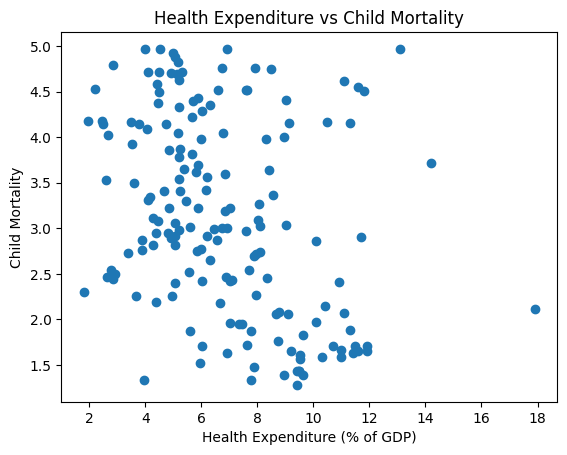

In [167]:
#Health Expenditure vs Child Mortality
plt.scatter(data['health'], data['child_mort'])
plt.xlabel('Health Expenditure (% of GDP)')
plt.ylabel('Child Mortality')
plt.title('Health Expenditure vs Child Mortality')
plt.show()
#Negative Correlation,As health expenditure increases,Child mortality decreases


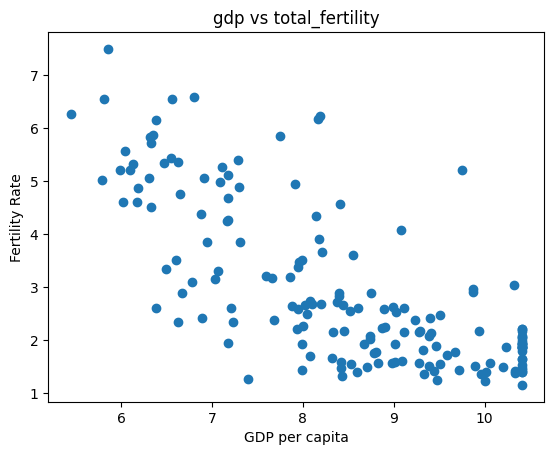

In [168]:
#GDP vs Fertility Rate
plt.scatter(data['gdpp'], data['total_fer'])
plt.xlabel('GDP per capita')
plt.ylabel('Fertility Rate')
plt.title('gdp vs total_fertility')
plt.show()
#Strong Negative Correlation,As GDP per capita increases.Fertility rate decreases


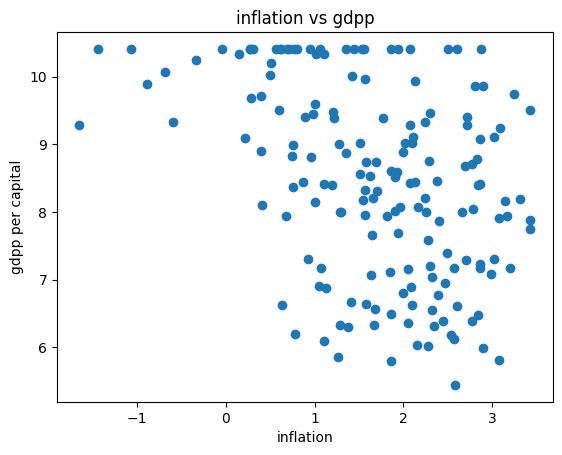

In [169]:
#Inflation vs GDP
plt.scatter(data['inflation'], data['gdpp'])
plt.xlabel('inflation')
plt.ylabel('gdpp per capital')
plt.title('inflation vs gdpp')
plt.show()
#Countries with both high and low GDP exhibit varying inflation rates,
# indicating that inflation is influenced by short-term economic conditions rather than long-term economic development.
#Inflation does not consistently increase or decrease with GDP,Pattern looks scattered/random

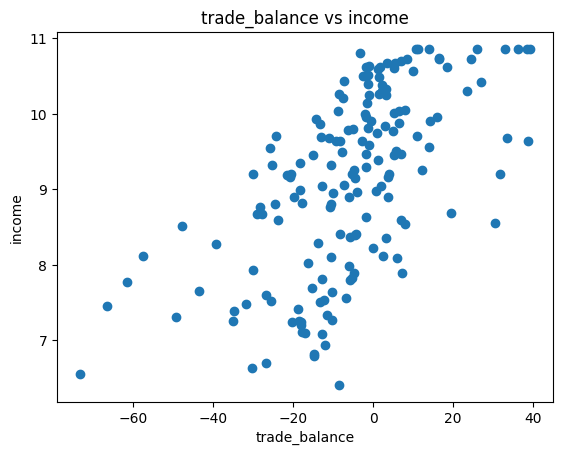

In [170]:
#Trade Balance vs Income
plt.scatter(data['Trade_Balance'], data['income'])
plt.xlabel('trade_balance')
plt.ylabel('income')
plt.title('trade_balance vs income')
plt.show()
#Countries with both high and low income levels can experience either trade surplus or deficit,
#indicating that income is influenced by multiple economic factors beyond trade balance.

# Correlation Analysis


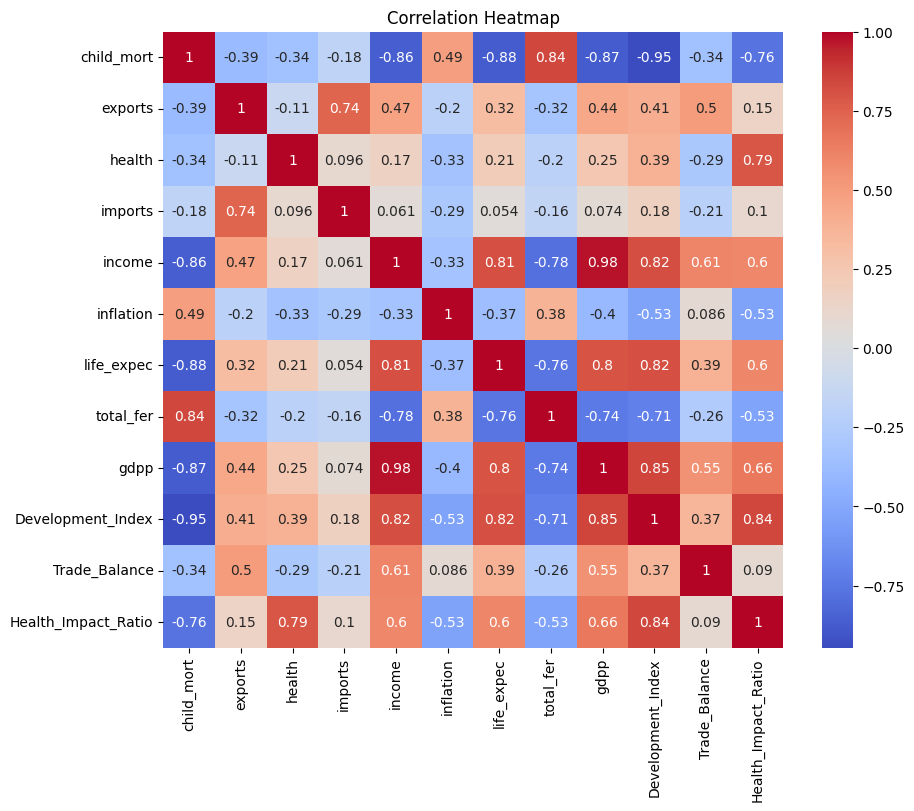

In [171]:
#Correlation heatmap
# select only numeric columns
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
# positive corelation
#income ↔ gdpp,income ↔ life_expec,gdpp ↔ life_expec (Rich countries → better living conditions)

1.Identify strongest predictors of life expectancy and mortality.

*   Higher income & GDP → better healthcare, nutrition → longer life
*  Countries with high mortality & fertility → lower life expectancy




# Rule-Based Country Segmentation

In [177]:
import numpy as np

# We must wrap the threshold numbers in np.log1p()
# because the data itself is log-transformed.
conditions = [
    (data['child_mort'] > np.log1p(80)) & (data['income'] < np.log1p(5000)),
    (data['income'] > np.log1p(30000)) & (data['life_expec'] > 78),
    (data['income'].between(np.log1p(8000), np.log1p(30000))),
    (data['inflation'] > np.log1p(15)), # Adjusted for your signed-log transform
    (data['health'] < 5) & (data['child_mort'] > np.log1p(70)),
    (data['gdpp'] < np.log1p(2000))
]

choices = [
    "High Risk Country",
    "Developed Nation",
    "Emerging Economy",
    "High Inflation Risk",
    "Health Critical",
    "Low GDP Trap"
]

# Apply to 'data' (ensure you use 'data' in your SQL/Analysis cells later)
data['Segment'] = np.select(conditions, choices, default="Other")

# Preview the results
data[['country', 'income', 'gdpp', 'Segment']].head(10)

,country,income,gdpp,Segment
0,Afghanistan,7.384610,6.317165,High Risk Country
1,Albania,9.203416,8.316545,Emerging Economy
2,Algeria,9.465060,8.403128,Emerging Economy
3,Angola,8.682877,8.169336,High Inflation Risk
4,Antigua and Barbuda,9.857496,9.409273,Emerging Economy
5,Argentina,9.836332,9.239996,Emerging Economy
6,Armenia,8.810012,8.077447,Other
7,Australia,10.631060,10.408225,Developed Nation
8,Austria,10.673619,10.408225,Developed Nation
9,Azerbaijan,9.680406,8.672657,Emerging Economy


In [178]:
data

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance,Health_Impact_Ratio,Segment
0,Afghanistan,4.513055,10.0,7.58,44.9,7.384610,2.345645,56.2,5.82,6.317165,15.488793,-34.9,1.679572,High Risk Country
1,Albania,2.867899,28.0,6.55,48.6,9.203416,1.702928,76.3,1.65,8.316545,32.713831,-20.6,2.283902,Emerging Economy
2,Algeria,3.342862,38.4,4.17,31.4,9.465060,2.839078,76.5,2.89,8.403128,28.229761,7.0,1.247434,Emerging Economy
3,Angola,4.787492,62.3,2.85,42.9,8.682877,3.152736,60.1,6.16,8.169336,16.073597,19.4,0.595301,High Inflation Risk
4,Antigua and Barbuda,2.424803,45.5,6.03,58.9,9.857496,0.891998,76.8,2.13,9.409273,39.618386,-13.4,2.486800,Emerging Economy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,3.407842,46.6,5.25,52.7,7.989899,1.286474,63.0,3.50,7.996654,23.177881,-6.1,1.540564,Other
163,Venezuela,2.895912,28.5,4.91,17.6,9.711176,3.433987,75.4,2.47,9.510519,32.674231,10.9,1.695494,Emerging Economy
164,Vietnam,3.190476,72.0,6.84,80.2,8.409831,2.572612,73.1,1.95,7.178545,27.797848,-8.2,2.143880,Low GDP Trap
165,Yemen,4.048301,30.0,5.18,34.4,8.407602,3.202746,67.5,4.67,7.178545,20.523710,-4.4,1.279549,High Inflation Risk


# SQL

In [179]:
#Average income per segment.
data.groupby('Segment')['income'].mean()

,income
Segment,
Developed Nation,10.638451
Emerging Economy,9.636326
Health Critical,8.289288
High Inflation Risk,8.963746
High Risk Country,7.311236
Low GDP Trap,7.818180
Other,8.909022


In [180]:
#Top 10 high-risk countries.
high_risk = data[data['Segment'] == 'High Risk Country']

high_risk.sort_values(by='child_mort', ascending=False).head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Development_Index,Trade_Balance,Health_Impact_Ratio,Segment
32,Chad,4.968945,36.8,4.53,43.5,7.565793,2.000128,56.5,6.59,6.800170,14.261773,-6.7,0.911662,High Risk Country
31,Central African Republic,4.968945,11.8,3.98,26.5,6.790097,1.101940,47.5,5.21,6.102559,12.154020,-14.7,0.800975,High Risk Country
132,Sierra Leone,4.968945,16.8,13.10,34.5,7.107425,2.901422,55.0,5.20,5.991465,13.704899,-17.7,2.636375,High Risk Country
66,Haiti,4.968945,15.3,6.91,64.7,7.313887,1.864080,32.1,3.33,6.496775,9.239519,-49.4,1.390637,High Risk Country
97,Mali,4.927254,22.8,4.98,35.1,7.534228,1.680828,59.5,6.55,6.563856,14.936938,-12.3,1.010705,High Risk Country
112,Niger,4.820282,22.2,5.16,49.1,6.703188,1.266948,58.8,7.49,5.855072,14.803753,-26.9,1.070477,High Risk Country
37,"Congo, Dem. Rep.",4.762174,41.1,7.91,49.6,6.413459,3.081910,57.5,6.54,5.814131,14.641966,-8.5,1.661006,High Risk Country
25,Burkina Faso,4.762174,19.2,6.74,29.6,7.266129,2.055405,57.9,5.87,6.356108,15.018821,-10.4,1.415320,High Risk Country
64,Guinea-Bissau,4.744932,14.9,8.50,35.2,7.237778,1.378766,55.6,5.05,6.306275,14.572190,-20.3,1.791385,High Risk Country
40,Cote d'Ivoire,4.718499,50.6,5.30,43.3,7.897668,1.854734,56.3,5.27,7.107425,15.111817,7.3,1.123239,High Risk Country


In [181]:
#Countries with highest inflation
data[['country','inflation']] \
.sort_values(by='inflation', ascending=False) \
.head(10)

,country,inflation
103,Mongolia,3.433987
163,Venezuela,3.433987
113,Nigeria,3.433987
149,Timor-Leste,3.314186
49,Equatorial Guinea,3.254243
165,Yemen,3.202746
140,Sri Lanka,3.169686
3,Angola,3.152736
5,Argentina,3.086487
37,"Congo, Dem. Rep.",3.081910


In [182]:
#Countries with lowest GDP per capita.
data[['country','gdpp']] \
.sort_values(by='gdpp') \
.head(10)

,country,gdpp
26,Burundi,5.446737
88,Liberia,5.793014
37,"Congo, Dem. Rep.",5.814131
112,Niger,5.855072
132,Sierra Leone,5.991465
93,Madagascar,6.025866
106,Mozambique,6.040255
31,Central African Republic,6.102559
94,Malawi,6.131226
50,Eritrea,6.180017


In [183]:
#Fertility rate comparison across segments.
data.groupby('Segment')['total_fer'].mean()

,total_fer
Segment,
Developed Nation,1.748462
Emerging Economy,2.107969
Health Critical,3.150000
High Inflation Risk,4.107143
High Risk Country,5.380385
Low GDP Trap,3.524118
Other,2.710000
